In [5]:
#Exploratory Data Analysis (EDA) in machine learning is the critical initial process of analyzing,
# visualizing, and summarizing datasets to uncover underlying patterns, detect anomalies,
# test assumptions, and check data quality. It guides feature selection, data cleaning, and
# model selection, preventing "black box" outcomes. 

In [6]:
#Import and Load full Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load full dataset
df = pd.read_csv('../Dataset/covid.csv', low_memory=False)

# Recreate death column
df['death'] = df['date_died'].apply(lambda x: 1 if x == '9999-99-99' else 2)

# Keep only confirmed positive cases
df_positive = df[df['covid_res'] == 1].copy()

print(f"Full positive dataset shape: {df_positive.shape}")
print(f"\nDeath distribution:")
print(df_positive['death'].value_counts())
print(f"\nDeath % breakdown:")
print(df_positive['death'].value_counts(normalize=True) * 100)

Full positive dataset shape: (220657, 24)

Death distribution:
death
1    193536
2     27121
Name: count, dtype: int64

Death % breakdown:
death
1    87.708978
2    12.291022
Name: proportion, dtype: float64


In [7]:
#Check all columns for missing values
# In this dataset missing values are coded as 97, 98, 99
# We need to find which columns have them and how many

# Columns that can have missing value codes (not date or id columns)
check_cols = ['sex', 'patient_type', 'intubed', 'pneumonia', 'age', 'pregnancy',
              'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension', 
              'other_disease', 'cardiovascular', 'obesity', 'renal_chronic', 
              'tobacco', 'contact_other_covid', 'icu']

print("Missing value analysis (codes 97, 98, 99):")
print("="*55)

missing_info = []
for col in check_cols:
    total = len(df_positive)
    missing_count = df_positive[col].isin([97, 98, 99]).sum()
    missing_pct = (missing_count / total) * 100
    unique_vals = sorted(df_positive[col].unique().tolist())
    
    missing_info.append({
        'Column': col,
        'Missing_Count': missing_count,
        'Missing_%': round(missing_pct, 2),
        'Unique_Values': unique_vals
    })
    
    print(f"{col:<20} | Missing: {missing_count:>6} ({missing_pct:>6.2f}%) | Values: {unique_vals}")

missing_df = pd.DataFrame(missing_info)
print("\n")
print("Columns with HIGH missing % (>30%) - consider dropping:")
high_missing = missing_df[missing_df['Missing_%'] > 30]
print(high_missing[['Column', 'Missing_%']].to_string(index=False))

Missing value analysis (codes 97, 98, 99):
sex                  | Missing:      0 (  0.00%) | Values: [1, 2]
patient_type         | Missing:      0 (  0.00%) | Values: [1, 2]
intubed              | Missing: 152446 ( 69.09%) | Values: [1, 2, 97, 99]
pneumonia            | Missing:      3 (  0.00%) | Values: [1, 2, 99]
age                  | Missing:     81 (  0.04%) | Values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 105, 106, 114, 116, 119, 120]
pregnancy            | Missing: 121483 ( 55.06%) | Values: [1, 2, 97, 98]
diabetes             | Missing:    852 (  0.39%) | Values: [1, 2, 98]
copd                 | Missing:    76

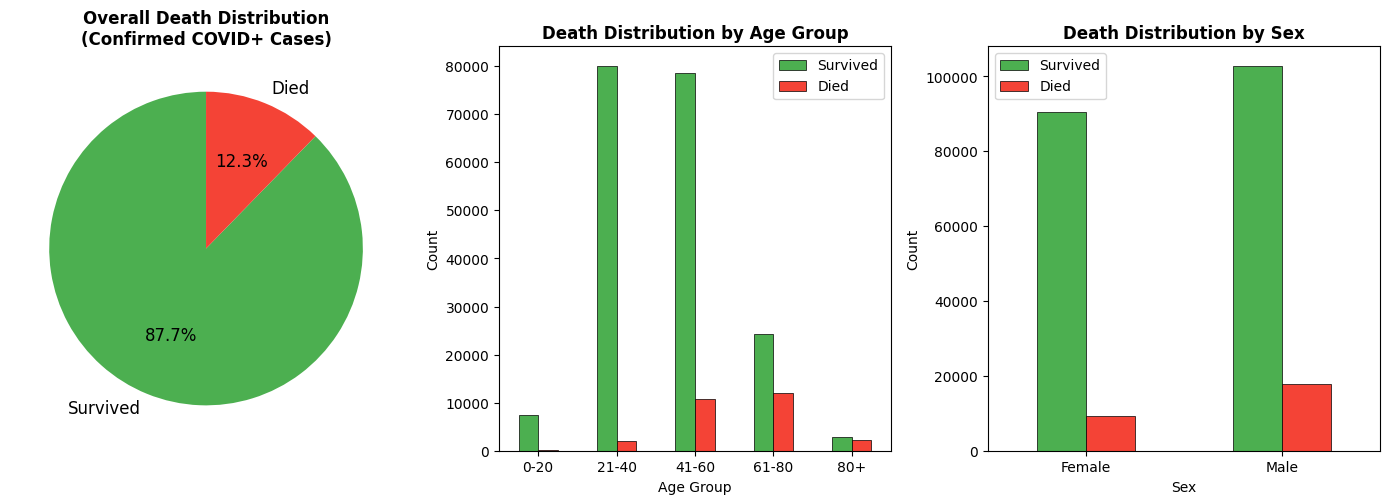

Class imbalance visualization saved!


In [8]:
#Class imbalance visualization
plt.figure(figsize=(14, 5))

# Plot 1: Overall death distribution
plt.subplot(1, 3, 1)
death_counts = df_positive['death'].map({1: 'Survived', 2: 'Died'}).value_counts()
colors = ['#4CAF50', '#F44336']
wedges, texts, autotexts = plt.pie(death_counts, labels=death_counts.index, 
                                    autopct='%1.1f%%', colors=colors,
                                    startangle=90, textprops={'fontsize': 12})
plt.title('Overall Death Distribution\n(Confirmed COVID+ Cases)', 
          fontweight='bold', fontsize=12)

# Plot 2: Death by age group
plt.subplot(1, 3, 2)
df_positive['age_group'] = pd.cut(df_positive['age'], 
                                   bins=[0, 20, 40, 60, 80, 120],
                                   labels=['0-20', '21-40', '41-60', '61-80', '80+'])
age_death = df_positive.groupby(['age_group', 'death']).size().unstack()
age_death.columns = ['Survived', 'Died']
age_death.plot(kind='bar', ax=plt.gca(), color=['#4CAF50', '#F44336'], 
               edgecolor='black', linewidth=0.5)
plt.title('Death Distribution by Age Group', fontweight='bold', fontsize=12)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()

# Plot 3: Death by sex
plt.subplot(1, 3, 3)
sex_death = df_positive.groupby(['sex', 'death']).size().unstack()
sex_death.index = ['Female', 'Male']
sex_death.columns = ['Survived', 'Died']
sex_death.plot(kind='bar', ax=plt.gca(), color=['#4CAF50', '#F44336'],
               edgecolor='black', linewidth=0.5)
plt.title('Death Distribution by Sex', fontweight='bold', fontsize=12)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.savefig('phase2_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class imbalance visualization saved!")

In [9]:
#Chronic Disease Impact Analysis
# Analyze how each chronic disease affects death rate
chronic_cols = ['diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension', 
                'other_disease', 'cardiovascular', 'obesity', 'renal_chronic', 
                'tobacco', 'pneumonia']

print("Death rate analysis by chronic disease:")
print("="*60)
print(f"{'Disease':<20} | {'Has Disease':>12} | {'No Disease':>12} | {'Difference':>10}")
print("-"*60)

death_rates = []
for col in chronic_cols:
    # Only look at valid values (1=yes, 2=no)
    df_valid = df_positive[df_positive[col].isin([1, 2])].copy()
    df_valid['died'] = df_valid['death'].map({1: 0, 2: 1})
    
    has_disease = df_valid[df_valid[col] == 1]['died'].mean() * 100
    no_disease = df_valid[df_valid[col] == 2]['died'].mean() * 100
    diff = has_disease - no_disease
    
    death_rates.append({
        'Disease': col,
        'Has_Disease_%': round(has_disease, 2),
        'No_Disease_%': round(no_disease, 2),
        'Difference_%': round(diff, 2)
    })
    
    print(f"{col:<20} | {has_disease:>11.2f}% | {no_disease:>11.2f}% | {diff:>+10.2f}%")

death_rates_df = pd.DataFrame(death_rates).sort_values('Difference_%', ascending=False)

Death rate analysis by chronic disease:
Disease              |  Has Disease |   No Disease | Difference
------------------------------------------------------------
diabetes             |       27.63% |        9.23% |     +18.41%
copd                 |       34.38% |       11.85% |     +22.53%
asthma               |        9.17% |       12.34% |      -3.17%
inmsupr              |       25.76% |       12.06% |     +13.70%
hypertension         |       25.73% |        8.86% |     +16.87%
other_disease        |       21.95% |       11.95% |     +10.00%
cardiovascular       |       27.84% |       11.87% |     +15.97%
obesity              |       15.70% |       11.39% |      +4.30%
renal_chronic        |       37.86% |       11.68% |     +26.18%
tobacco              |       13.82% |       12.12% |      +1.70%
pneumonia            |       39.10% |        3.81% |     +35.29%


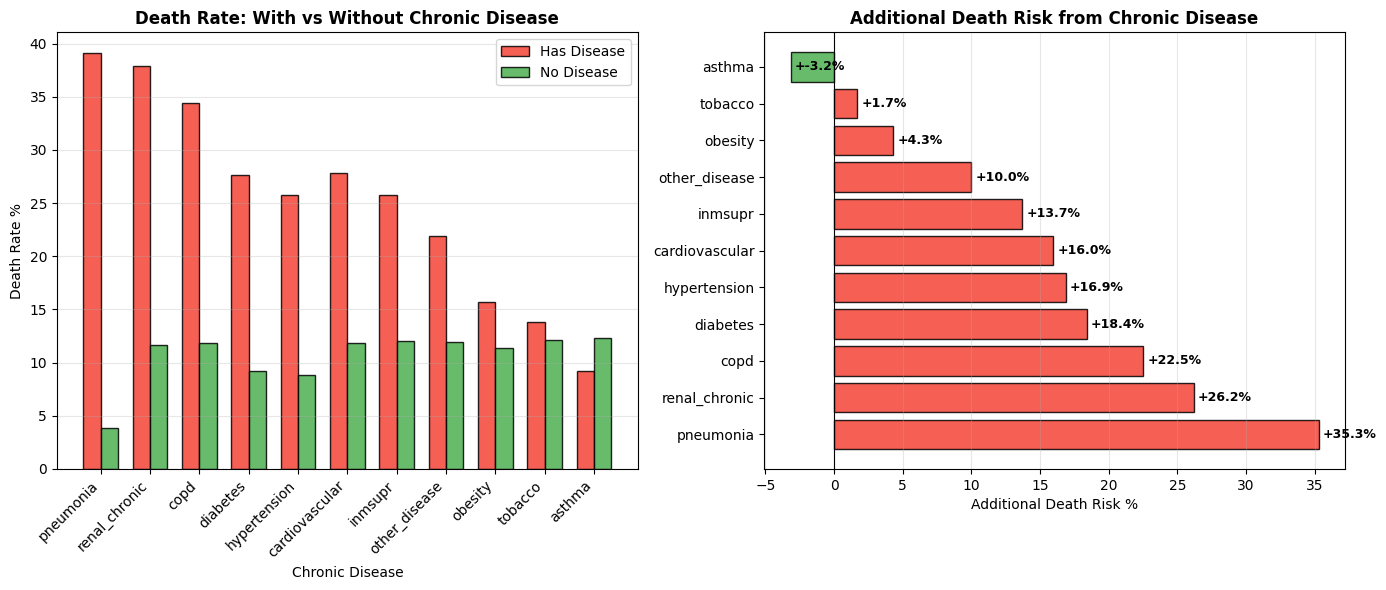

In [10]:
#Visualise chronic disease death rates
plt.figure(figsize=(14, 6))

# Plot 1: Death rate with vs without disease
plt.subplot(1, 2, 1)
x = np.arange(len(death_rates_df))
width = 0.35
bars1 = plt.bar(x - width/2, death_rates_df['Has_Disease_%'], width, 
                label='Has Disease', color='#F44336', alpha=0.85, edgecolor='black')
bars2 = plt.bar(x + width/2, death_rates_df['No_Disease_%'], width,
                label='No Disease', color='#4CAF50', alpha=0.85, edgecolor='black')
plt.xlabel('Chronic Disease')
plt.ylabel('Death Rate %')
plt.title('Death Rate: With vs Without Chronic Disease', fontweight='bold')
plt.xticks(x, death_rates_df['Disease'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Plot 2: Difference in death rate
plt.subplot(1, 2, 2)
colors_diff = ['#F44336' if x > 0 else '#4CAF50' for x in death_rates_df['Difference_%']]
bars = plt.barh(death_rates_df['Disease'], death_rates_df['Difference_%'], 
                color=colors_diff, edgecolor='black', alpha=0.85)
plt.xlabel('Additional Death Risk %')
plt.title('Additional Death Risk from Chronic Disease', fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, death_rates_df['Difference_%']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'+{val:.1f}%', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('phase2_chronic_disease_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

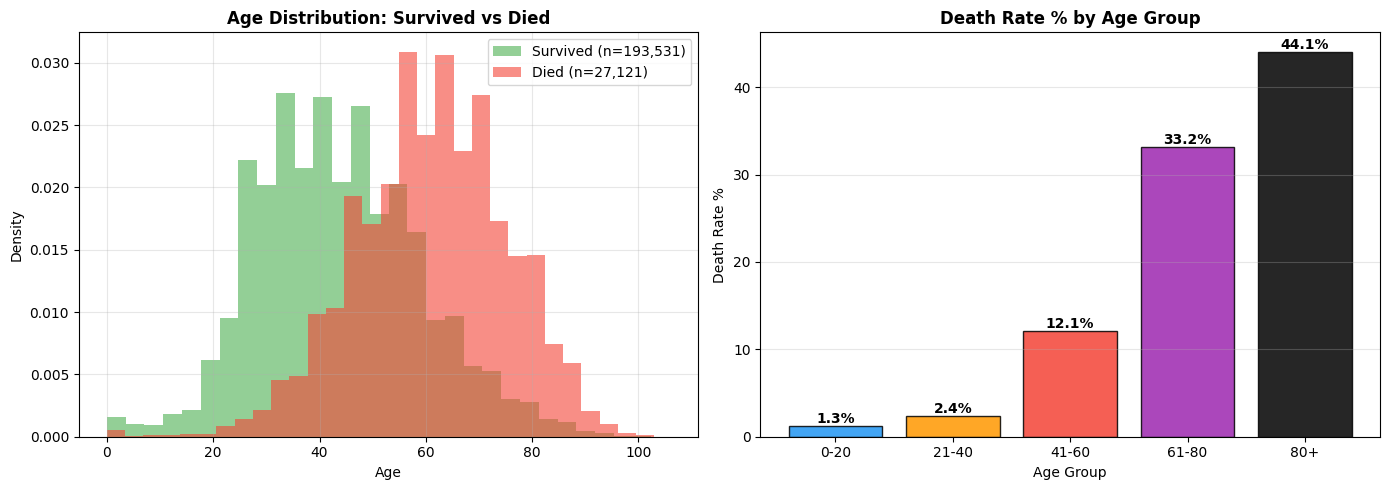


Key Age Statistics:
Average age of survivors: 43.5 years
Average age of deceased: 61.0 years
Death rate for 60+ patients: 33.6%
Death rate for under 40 patients: 2.1%


In [11]:
#Age Distribution Analysis
plt.figure(figsize=(14, 5))

# Filter valid ages
df_age = df_positive[df_positive['age'] <= 110].copy()
df_age['died'] = df_age['death'].map({1: 0, 2: 1})

# Plot 1: Age distribution survived vs died
plt.subplot(1, 2, 1)
survived_ages = df_age[df_age['died'] == 0]['age']
died_ages = df_age[df_age['died'] == 1]['age']
plt.hist(survived_ages, bins=30, alpha=0.6, color='#4CAF50', 
         label=f'Survived (n={len(survived_ages):,})', density=True)
plt.hist(died_ages, bins=30, alpha=0.6, color='#F44336', 
         label=f'Died (n={len(died_ages):,})', density=True)
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution: Survived vs Died', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Death rate by age group
plt.subplot(1, 2, 2)
age_group_death = df_age.groupby('age_group')['died'].mean() * 100
bars = plt.bar(age_group_death.index, age_group_death.values,
               color=['#2196F3', '#FF9800', '#F44336', '#9C27B0', '#000000'],
               edgecolor='black', alpha=0.85)
plt.xlabel('Age Group')
plt.ylabel('Death Rate %')
plt.title('Death Rate % by Age Group', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, age_group_death.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('phase2_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Age Statistics:")
print(f"Average age of survivors: {survived_ages.mean():.1f} years")
print(f"Average age of deceased: {died_ages.mean():.1f} years")
print(f"Death rate for 60+ patients: {df_age[df_age['age']>=60]['died'].mean()*100:.1f}%")
print(f"Death rate for under 40 patients: {df_age[df_age['age']<40]['died'].mean()*100:.1f}%")

In [12]:
#EDA Summary
print("="*60)
print("PHASE 2 - EDA SUMMARY")
print("="*60)

total = len(df_positive)
died = (df_positive['death'] == 2).sum()
survived = (df_positive['death'] == 1).sum()

print(f"\nDataset: {total:,} confirmed COVID-19 positive patients")
print(f"Survived: {survived:,} ({survived/total*100:.1f}%)")
print(f"Died: {died:,} ({died/total*100:.1f}%)")
print(f"\nClass Imbalance Ratio: {survived//died}:1 (survived:died)")

print(f"\nTop risk factors by additional death rate:")
print(death_rates_df[['Disease', 'Difference_%']].head(5).to_string(index=False))

print(f"\nAge insights:")
print(f"  Average age survivors: {survived_ages.mean():.1f}")
print(f"  Average age deceased: {died_ages.mean():.1f}")

print(f"\nMissing data concern:")
high_missing = missing_df[missing_df['Missing_%'] > 30]
if len(high_missing) > 0:
    print(f"  Columns with >30% missing: {high_missing['Column'].tolist()}")
else:
    print("  No columns with >30% missing data")

print("\nPhase 2 Complete!")
print("Key finding: Data is imbalanced ~88:12, needs fixing in Phase 3")

PHASE 2 - EDA SUMMARY

Dataset: 220,657 confirmed COVID-19 positive patients
Survived: 193,536 (87.7%)
Died: 27,121 (12.3%)

Class Imbalance Ratio: 7:1 (survived:died)

Top risk factors by additional death rate:
      Disease  Difference_%
    pneumonia         35.29
renal_chronic         26.18
         copd         22.53
     diabetes         18.41
 hypertension         16.87

Age insights:
  Average age survivors: 43.5
  Average age deceased: 61.0

Missing data concern:
  Columns with >30% missing: ['intubed', 'pregnancy', 'contact_other_covid', 'icu']

Phase 2 Complete!
Key finding: Data is imbalanced ~88:12, needs fixing in Phase 3
